In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
import sys, os

sys.path.append(os.path.join(os.getcwd(), '..'))
from config import RAW_DATA_PATH, PROCESSED_DATA_PATH, TARGET, HINT_FEATURES

In [78]:
df = pd.read_csv(RAW_DATA_PATH)
print("Original shape:", df.shape)

Original shape: (9082, 3925)


In [79]:
# Drop >50% missing columns
thresh = len(df) * 0.5
df_clean = df.dropna(axis=1, thresh=thresh)
print(f"After dropping >50% null columns: {df_clean.shape}")

# Drop unnamed index column if present
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' index column")

# Drop constant columns (same value in every row — useless for ML)
constant_cols = [col for col in df_clean.columns
                 if df_clean[col].nunique(dropna=False) <= 1]
df_clean = df_clean.drop(columns=constant_cols)
print(f"Dropped {len(constant_cols)} constant columns")

print(f"Shape after all cleaning: {df_clean.shape}")

After dropping >50% null columns: (9082, 2787)
Dropped 'Unnamed: 0' index column
Dropped 1 constant columns
Shape after all cleaning: (9082, 2785)


In [80]:
y = df_clean[TARGET].copy()
X = df_clean.drop(columns=[TARGET])
print(f"Features: {X.shape}, Target: {y.shape}")

Features: (9082, 2784), Target: (9082,)


In [81]:
X_num = X.select_dtypes(include=[np.number])
print(f"Numeric columns kept: {X_num.shape[1]}")
dropped_non_numeric = X.shape[1] - X_num.shape[1]
print(f"Non-numeric columns dropped: {dropped_non_numeric}")

Numeric columns kept: 2776
Non-numeric columns dropped: 8


In [82]:
X_filled = X_num.fillna(X_num.median())
print("Null values remaining:", X_filled.isnull().sum().sum())

Null values remaining: 0


In [83]:
available_hints = [f for f in HINT_FEATURES if f in X_filled.columns]
dropped_hints   = [f for f in HINT_FEATURES if f not in X_filled.columns]

print(f"Hint features available : {len(available_hints)} / {len(HINT_FEATURES)}")
print(f"Available : {available_hints}")
print(f"Dropped   : {dropped_hints}")

Hint features available : 15 / 18
Available : ['F115', 'F321', 'F527', 'F531', 'F670', 'F1692', 'F2082', 'F2122', 'F2582', 'F2678', 'F2737', 'F2956', 'F3836', 'F3887', 'F3894']
Dropped   : ['F3043', 'F3889', 'F3891']


In [84]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold

# Use only training indices for feature selection
from sklearn.model_selection import train_test_split

X_temp = X_filled.copy()
y_temp = y.copy()

# Remove target if inside
if TARGET in X_temp.columns:
    X_temp = X_temp.drop(columns=[TARGET])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    stratify=y_temp,
    random_state=42
)

# Fit selector ONLY on training portion
K = 30  # strict — only 30 features to force generalization
selector = SelectKBest(score_func=f_classif, k=min(K, X_tr.shape[1]))
selector.fit(X_tr, y_tr)

selected_mask     = selector.get_support()
selected_features = X_tr.columns[selected_mask].tolist()

# Add hint features from bank (domain knowledge)
for h in available_hints:
    if h in X_filled.columns and h not in selected_features:
        selected_features.append(h)

# Remove index-like columns
selected_features = [f for f in selected_features
                     if 'unnamed' not in f.lower()]

print(f"Total features selected: {len(selected_features)}")
print(selected_features)

Total features selected: 45
['F157', 'F159', 'F160', 'F162', 'F265', 'F267', 'F268', 'F270', 'F886', 'F1936', 'F1938', 'F2074', 'F2076', 'F2182', 'F2285', 'F2481', 'F2578', 'F2779', 'F3226', 'F3228', 'F3229', 'F3231', 'F3337', 'F3339', 'F3445', 'F3447', 'F3502', 'F3504', 'F3908', 'F3912', 'F115', 'F321', 'F527', 'F531', 'F670', 'F1692', 'F2082', 'F2122', 'F2582', 'F2678', 'F2737', 'F2956', 'F3836', 'F3887', 'F3894']


c:\mule-account-detection\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 198  199  200  201  202  203  222  223  224  225  226  227  228  229
  230  231  232  233  234  235  236  237  238  239  240  241  242  243
  244  245  270  271  272  273  274  275  276  277  278  279  280  281
  282  283  284  285  286  287  306  307  308  309  310  311  330  331
  332  333  334  335  336  337  338  339  340  341  342  343  344  345
  346  347  348  349  350  351  352  353  373  376  378  379  380  381
  382  383  384  385  386  387  388  389  390  391  392  393  394  395
  402  403  404  405  406  407  414  415  416  417  418  419  438  439
  440  441  442  443  445  448  450  451  452  453  454  455  456  457
  458  459  460  461  464  467  476  479  481  482  484  485  486  487
  488  489  490  491  492  493  494  495  496  497  498  499  500  501
  502  503  505  508  510  511  512  513  514  515  547  550  600  601
  602  603  604  605 

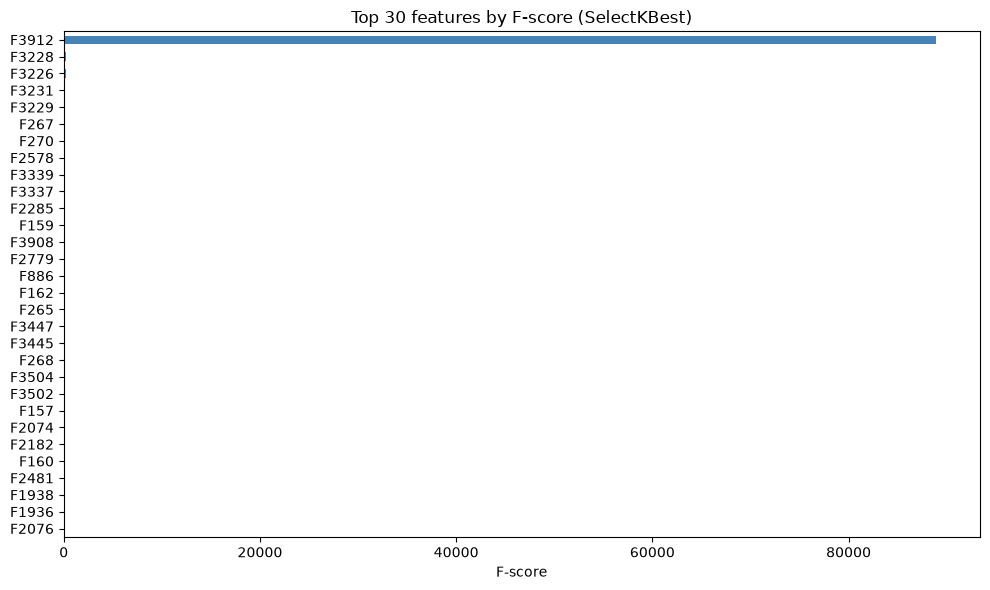

In [85]:
scores = pd.Series(selector.scores_, index=X_filled.columns)
top30  = scores.nlargest(30)

plt.figure(figsize=(10, 6))
top30.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 30 features by F-score (SelectKBest)")
plt.xlabel("F-score")
plt.tight_layout()
plt.savefig("../reports/figures/feature_scores.png")
plt.show()

In [86]:
X_selected = X_filled[selected_features].copy()
X_selected[TARGET] = y.values

print("Final dataset shape:", X_selected.shape)
X_selected.head()

Final dataset shape: (9082, 46)


,F157,F159,F160,F162,F265,F267,F268,F270,F886,F1936,...,F2082,F2122,F2582,F2678,F2737,F2956,F3836,F3887,F3894,F3924
0,0.53,0.50,0.51,0.56,0.31,0.19,0.33,0.35,1.0,0.0,...,0.0,0.009091,-0.08,-0.12,-0.16,36.0,29814.53,170,30.0,0
1,0.34,0.33,0.17,0.19,0.27,0.26,0.17,0.18,0.0,0.0,...,0.0,0.000000,-0.25,-0.47,-0.05,99.0,371320.98,169,32.0,0
2,0.42,0.39,0.60,0.56,0.32,0.26,0.57,0.54,0.0,0.0,...,0.0,0.000000,-0.21,-0.46,0.00,100.0,546659.78,170,32.0,0
3,0.71,0.71,0.44,0.43,0.31,0.32,0.31,0.33,0.0,0.0,...,0.0,0.000000,0.09,-0.46,0.66,56.0,353339.72,170,45.0,0
4,0.52,0.54,0.60,0.56,0.25,0.25,0.21,0.20,0.0,0.0,...,0.0,0.000000,0.65,-0.42,-0.53,63.0,1116.11,171,30.0,0


In [87]:
os.makedirs(os.path.join(os.getcwd(), '../data/processed'), exist_ok=True)
save_path = os.path.join(os.getcwd(), '../data/processed/features.csv')

X_selected.to_csv(save_path, index=False)
print(f"Saved to: {save_path}")

Saved to: c:\mule-account-detection\notebooks\../data/processed/features.csv


In [88]:
import json

feat_path = os.path.join(os.getcwd(), '../data/processed/selected_features.json')
with open(feat_path, 'w') as f:
    json.dump(selected_features, f)

print(f"Feature list saved: {len(selected_features)} features")

Feature list saved: 45 features
